<a href="https://colab.research.google.com/github/EmiiFernandez/actividades_data_sciente_ypf/blob/main/notebook/C18_Noteboook-22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

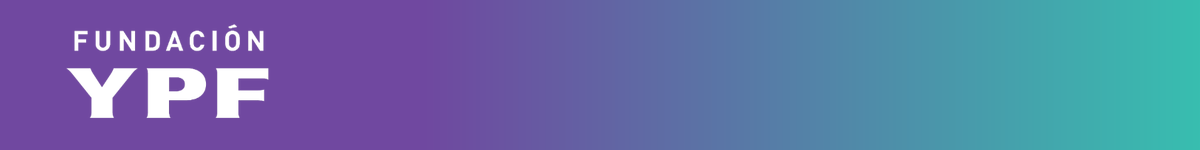

# Fundación YPF - Data Science

## Notebook 22: Práctica II, modelo de regresión

### Índice de partes

* **Parte 0:** Preparación del entorno y carga de los datos
* **Parte 1:** Repaso de regresión, métricas y validación cruzada
* **Parte 2:** Análisis exploratorio y preparación de los datos
* **Parte 3:** Modelos base y evaluación
* **Parte 4:** Validación cruzada y ajuste de hiperparámetros
* **Parte 5:** Selección e interpretación del modelo
* **Parte 6:** Ejercicio para las salas de Zoom

## Parte 0: Preparación del entorno y carga de los datos

En esta práctica recorremos **todo el flujo de un modelo de regresión**: desde el análisis exploratorio hasta la evaluación y la selección del mejor modelo. Además de aplicar lo visto en las últimas clases, repasamos las métricas (clase 15), la validación cruzada (clase 16) y la forma de trabajo de la práctica anterior (clase 17).

**Dataset:** `life_expectancy_data.csv`. Contiene indicadores de salud, economía y educación de 193 países entre 2000 y 2015 (fuente: Organización Mundial de la Salud). Cada fila es un país en un año.

**Problema:** predecir la **esperanza de vida** (`Life expectancy`) a partir del resto de los indicadores.

Antes de ejecutar, subí el archivo `life_expectancy_data.csv` al panel de archivos de Colab (ícono de carpeta a la izquierda).

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [ ]:
# Si el archivo no está en Colab, se abre un cuadro para subirlo
if not os.path.exists("life_expectancy_data.csv"):
    from google.colab import files
    files.upload()

df = pd.read_csv("life_expectancy_data.csv")
df.shape

## Parte 1: Repaso de regresión, métricas y validación cruzada

**Regresión:** el modelo predice un **valor numérico continuo** (acá, los años de esperanza de vida). En clasificación, en cambio, predice una categoría, como hicimos en la Notebook 21.

**Métricas de error**, donde $y_i$ es el valor real y $\hat{y}_i$ el valor predicho:

* **MAE** (error absoluto medio): $\frac{1}{n}\sum |y_i - \hat{y}_i|$. Se expresa en las mismas unidades que la variable objetivo (años).
* **RMSE** (raíz del error cuadrático medio): $\sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2}$. Penaliza más los errores grandes.
* **R²** (coeficiente de determinación): qué proporción de la variabilidad de $y$ explica el modelo. Vale 1 si el ajuste es perfecto y 0 si el modelo no mejora a predecir siempre el promedio.

**Overfitting:** el modelo memoriza los datos de entrenamiento y falla con datos nuevos. Lo detectamos cuando el desempeño en *train* es mucho mejor que en *test*.

**Validación cruzada:** en lugar de depender de una sola partición train/test, entrenamos y evaluamos varias veces con particiones distintas, y promediamos. Da una estimación más estable del desempeño.

**Hiperparámetros:** parámetros que fijamos antes de entrenar (por ejemplo, la profundidad de un árbol o la fuerza de la regularización en Ridge). Los elegimos con validación cruzada, nunca mirando el conjunto de test.

**Flujo de trabajo de hoy:** exploración, preparación, modelos base, validación cruzada, ajuste de hiperparámetros, evaluación final en test.

## Parte 2: Análisis exploratorio y preparación de los datos

### 2.1 Primer vistazo

In [ ]:
# Los nombres de las columnas traen espacios de más, los limpiamos
df.columns = df.columns.str.strip().str.replace(r"\s+", " ", regex=True)
df.head()

In [ ]:
df.info()

### 2.2 Valores faltantes

Calculamos el porcentaje de nulos por columna.

In [ ]:
nulos = (df.isna().mean() * 100).sort_values(ascending=False).round(1)
nulos[nulos > 0]

La variable objetivo también tiene nulos. **No podemos entrenar ni evaluar con filas sin la respuesta**, así que las eliminamos. Para las variables predictoras, en cambio, vamos a **imputar** más adelante dentro de un `Pipeline`, de modo que la mediana se calcule solo con los datos de entrenamiento.

In [ ]:
df = df.dropna(subset=["Life expectancy"]).copy()
print("Filas luego de quitar nulos en la variable objetivo:", df.shape[0])

### 2.3 Valores que no son plausibles

Algunas columnas tienen ceros que en realidad indican dato ausente: un país no puede tener cero años de escolaridad promedio.

In [ ]:
print((df[["Income composition of resources", "Schooling"]] == 0).sum())

for col in ["Income composition of resources", "Schooling"]:
    df.loc[df[col] == 0, col] = np.nan

### 2.4 La variable objetivo

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Life expectancy"], bins=30, kde=True, ax=ax[0], color="#7030A0")
ax[0].set_title("Distribución de la esperanza de vida")
sns.boxplot(data=df, x="Status", y="Life expectancy", ax=ax[1], palette=["#7030A0", "#30BEAA"])
ax[1].set_title("Esperanza de vida según el estatus del país")
plt.tight_layout()
plt.show()

### 2.5 Relación con las variables predictoras

In [ ]:
corr = df.select_dtypes("number").corr()["Life expectancy"].drop("Life expectancy").sort_values()
plt.figure(figsize=(8, 6))
corr.plot(kind="barh", color="#7030A0")
plt.title("Correlación de cada variable con la esperanza de vida")
plt.xlabel("Correlación de Pearson")
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.ravel(), ["Schooling", "Income composition of resources", "Adult Mortality", "HIV/AIDS"]):
    sns.scatterplot(data=df, x=col, y="Life expectancy", hue="Status", alpha=0.5, ax=ax, palette=["#7030A0", "#30BEAA"])
    ax.set_title(f"Esperanza de vida vs {col}")
plt.tight_layout()
plt.show()

**Qué observamos:**

* La escolaridad y la composición del ingreso se asocian de forma positiva con la esperanza de vida, y la mortalidad adulta y el VIH/SIDA de forma negativa.
* Algunas relaciones no son lineales (por ejemplo, `HIV/AIDS`), lo que sugiere probar modelos que no asuman una recta.
* Hay variables muy parecidas entre sí (`infant deaths` y `under-five deaths`, o las dos de `thinness`). Esa **multicolinealidad** afecta a la regresión lineal y es una razón para probar regularización (Ridge y Lasso).

### 2.6 Definir variables y partición de los datos

Decisiones que tomamos:

* **`Country` no entra como variable predictora**: tiene 193 categorías y no generaliza a países nuevos. Pero sí la usamos como **grupo** para particionar.
* **`Status` es categórica**, se codifica con *one hot*.
* Las numéricas se imputan con la mediana y se escalan.

**Una trampa importante:** cada país aparece 16 veces, una por año. Si partimos las filas al azar, un mismo país queda en train y en test, y el modelo "ya conoce" a ese país. El resultado sería demasiado optimista. Para evitarlo, usamos una partición **por grupos**: todos los años de un país van al mismo lado.

In [ ]:
y = df["Life expectancy"]
X = df.drop(columns=["Life expectancy", "Country"])
grupos = df["Country"]

cols_num = X.select_dtypes("number").columns.tolist()
cols_cat = ["Status"]

preprocesador = ColumnTransformer([
    ("num", Pipeline([("imputador", SimpleImputer(strategy="median")),
                      ("escalador", StandardScaler())]), cols_num),
    ("cat", OneHotEncoder(drop="first"), cols_cat),
])

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
idx_train, idx_test = next(gss.split(X, y, grupos))

X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
y_train, y_test = y.iloc[idx_train], y.iloc[idx_test]
g_train = grupos.iloc[idx_train]

print("Filas de train:", len(X_train), "| Filas de test:", len(X_test))
print("Países en común entre train y test:", len(set(grupos.iloc[idx_train]) & set(grupos.iloc[idx_test])))

## Parte 3: Modelos base y evaluación

Empezamos con un **modelo de referencia** (*baseline*): predecir siempre el promedio. Cualquier modelo útil tiene que superarlo.

Luego probamos modelos de complejidad creciente: regresión lineal, Ridge y Lasso (lineales con regularización), un árbol de decisión y un Random Forest.

In [ ]:
def evaluar(modelo, nombre):
    pipe = Pipeline([("prep", preprocesador), ("modelo", modelo)]).fit(X_train, y_train)
    pred_tr, pred_te = pipe.predict(X_train), pipe.predict(X_test)
    return pipe, {
        "Modelo": nombre,
        "R2 train": r2_score(y_train, pred_tr),
        "R2 test": r2_score(y_test, pred_te),
        "MAE test": mean_absolute_error(y_test, pred_te),
        "RMSE test": np.sqrt(mean_squared_error(y_test, pred_te)),
    }

modelos = {
    "Baseline (promedio)": DummyRegressor(),
    "Regresión lineal": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Árbol de decisión": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
}

pipes, filas = {}, []
for nombre, modelo in modelos.items():
    pipes[nombre], fila = evaluar(modelo, nombre)
    filas.append(fila)

resultados = pd.DataFrame(filas).set_index("Modelo").round(3)
resultados

**Cómo leer la tabla:**

* El *baseline* da un R² cercano a 0: no explica nada, como esperábamos.
* Los modelos lineales explican una buena parte de la variabilidad, con un desempeño parecido en train y en test.
* El **árbol de decisión** tiene un R² de train casi perfecto pero bastante menor en test: es un caso típico de **overfitting**.
* El **Random Forest** combina muchos árboles y logra el mejor resultado en test, aunque también se ajusta mucho al entrenamiento.

In [ ]:
mejor = pipes["Random Forest"]
pred = mejor.predict(X_test)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(y_test, pred, alpha=0.5, color="#7030A0")
lim = [y_test.min(), y_test.max()]
ax[0].plot(lim, lim, "--", color="#30BEAA")
ax[0].set_xlabel("Valor real")
ax[0].set_ylabel("Valor predicho")
ax[0].set_title("Random Forest: real vs predicho (test)")

sns.histplot(y_test - pred, bins=30, kde=True, ax=ax[1], color="#7030A0")
ax[1].set_title("Distribución de los errores (real menos predicho)")
ax[1].set_xlabel("Error en años")
plt.tight_layout()
plt.show()

### ¿Qué pasa si ignoramos los grupos?

Repetimos el Random Forest con una partición al azar de las filas, y comparamos.

In [ ]:
Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
rf_azar = Pipeline([("prep", preprocesador),
                    ("modelo", RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))]).fit(Xa, ya)

print("R2 en test con partición al azar:     ", round(r2_score(yb, rf_azar.predict(Xb)), 3))
print("R2 en test con partición por países:  ", round(resultados.loc["Random Forest", "R2 test"], 3))

La partición al azar da un resultado **más optimista**, porque el modelo ya vio a esos países en otros años. La partición por países refleja mejor lo que pasaría con un país nuevo, y es la que usamos en el resto de la práctica.

## Parte 4: Validación cruzada y ajuste de hiperparámetros

### 4.1 Validación cruzada por grupos

Una sola partición puede ser favorable o desfavorable por casualidad. Usamos **5 particiones** (`GroupKFold`), siempre manteniendo a cada país completo en un mismo lado, y evaluamos con R².

In [ ]:
cv = GroupKFold(n_splits=5)

cv_scores = {}
for nombre, modelo in modelos.items():
    pipe = Pipeline([("prep", preprocesador), ("modelo", modelo)])
    cv_scores[nombre] = cross_val_score(pipe, X_train, y_train, cv=cv, groups=g_train, scoring="r2", n_jobs=-1)

resumen_cv = pd.DataFrame({
    "R2 promedio": {k: v.mean() for k, v in cv_scores.items()},
    "Desvío": {k: v.std() for k, v in cv_scores.items()},
}).round(3)
resumen_cv

In [ ]:
plt.figure(figsize=(10, 4.5))
sns.boxplot(data=pd.DataFrame(cv_scores), color="#C9B3E0")
plt.xticks(rotation=20)
plt.ylabel("R2 en validación cruzada")
plt.title("Desempeño de cada modelo en 5 particiones")
plt.tight_layout()
plt.show()

El desvío entre particiones nos dice **cuánto confiar** en cada número. Un modelo con buen promedio pero mucha variabilidad es menos confiable.

### 4.2 Overfitting en árboles: el efecto de la profundidad

Un árbol más profundo se ajusta cada vez mejor a train. Veamos qué pasa con la validación cruzada.

In [ ]:
profundidades = range(1, 21)
r2_tr, r2_cv = [], []
for d in profundidades:
    pipe = Pipeline([("prep", preprocesador),
                     ("modelo", DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE))])
    r2_cv.append(cross_val_score(pipe, X_train, y_train, cv=cv, groups=g_train, scoring="r2", n_jobs=-1).mean())
    r2_tr.append(pipe.fit(X_train, y_train).score(X_train, y_train))

plt.figure(figsize=(9, 4.5))
plt.plot(profundidades, r2_tr, "o-", label="Train", color="#7030A0")
plt.plot(profundidades, r2_cv, "o-", label="Validación cruzada", color="#30BEAA")
plt.xlabel("Profundidad máxima del árbol")
plt.ylabel("R2")
plt.title("Curva de validación del árbol de decisión")
plt.legend()
plt.tight_layout()
plt.show()

La curva de train sigue subiendo, pero la de validación se estanca (o empeora). **La brecha entre ambas es el overfitting.** La profundidad óptima está donde la validación deja de mejorar (en este caso, cerca de 7).

### 4.3 Búsqueda de hiperparámetros con `GridSearchCV`

Probamos combinaciones de hiperparámetros con validación cruzada por grupos, solo sobre el conjunto de entrenamiento.

In [ ]:
busquedas = {
    "Ridge": (
        Ridge(),
        {"modelo__alpha": [0.01, 0.1, 1, 10, 100]},
    ),
    "Random Forest": (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {"modelo__n_estimators": [100, 300],
         "modelo__max_depth": [10, 20, None],
         "modelo__min_samples_leaf": [1, 3]},
    ),
}

mejores = {}
for nombre, (modelo, grilla) in busquedas.items():
    pipe = Pipeline([("prep", preprocesador), ("modelo", modelo)])
    gs = GridSearchCV(pipe, grilla, cv=cv, scoring="r2", n_jobs=-1)
    gs.fit(X_train, y_train, groups=g_train)
    mejores[nombre] = gs
    print(f"{nombre}: mejores hiperparámetros {gs.best_params_}")
    print(f"{nombre}: R2 en validación cruzada {gs.best_score_:.3f}\n")

## Parte 5: Selección e interpretación del modelo

### 5.1 Evaluación final en test

El conjunto de test se usa **una sola vez**, al final, con los modelos ya elegidos.

In [ ]:
finales = {
    "Regresión lineal (sin ajustar)": pipes["Regresión lineal"],
    "Ridge (ajustado)": mejores["Ridge"].best_estimator_,
    "Random Forest (sin ajustar)": pipes["Random Forest"],
    "Random Forest (ajustado)": mejores["Random Forest"].best_estimator_,
}

filas = []
for nombre, pipe in finales.items():
    pred = pipe.predict(X_test)
    filas.append({"Modelo": nombre,
                  "R2 test": r2_score(y_test, pred),
                  "MAE test": mean_absolute_error(y_test, pred),
                  "RMSE test": np.sqrt(mean_squared_error(y_test, pred))})

pd.DataFrame(filas).set_index("Modelo").round(3)

Elegimos el modelo con mejor desempeño en validación cruzada **y** en test, sin olvidar la **interpretabilidad**: a igual desempeño, un modelo más simple es preferible.

### 5.2 ¿Qué variables importan?

In [ ]:
rf = mejores["Random Forest"].best_estimator_
nombres = rf.named_steps["prep"].get_feature_names_out()
importancias = pd.Series(rf.named_steps["modelo"].feature_importances_, index=nombres)
importancias.index = importancias.index.str.replace("num__", "", regex=False).str.replace("cat__", "", regex=False)

plt.figure(figsize=(8, 5))
importancias.sort_values().tail(10).plot(kind="barh", color="#7030A0")
plt.title("Las 10 variables más importantes del Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

**Conclusiones para llevarnos:**

* Elegir un modelo implica mirar el desempeño, la estabilidad (desvío en validación cruzada), el overfitting y la interpretabilidad.
* La validación cruzada sirve para **decidir**; el test, para **informar** el desempeño final.
* Las importancias indican qué variables usa el modelo para predecir, pero **no prueban causalidad**.
* Cuando los datos tienen estructura (varias filas por país), la forma de particionar cambia el resultado.

## Parte 6: Ejercicio para las salas de Zoom

**Dataset:** `StudentsPerformance.csv`. Contiene los puntajes de 1000 estudiantes en tres exámenes y algunas características personales y familiares.

**Objetivo:** predecir el puntaje de matemática (`math score`) con el flujo completo que acabamos de ver.

**Tiempo:** 50 minutos. Al final, cada sala comparte sus conclusiones.

**Consigna:**

1. **Exploración.** Revisá los tipos de datos, los nulos y las estadísticas de cada columna. Prestá atención a las **escalas** de los tres puntajes: ¿son comparables? Si detectás algo raro, corregilo y justificá cómo.
2. **Análisis exploratorio.** Graficá la distribución de `math score` y su relación con las demás variables (por ejemplo, `reading score`, `writing score`, `lunch`, `test preparation course`).
3. **Preparación.** Definí variables predictoras y objetivo, y armá un `Pipeline` con el tratamiento de variables numéricas y categóricas.
4. **Partición.** Separá en train y test.
5. **Modelos.** Entrená un *baseline* y al menos tres modelos de regresión. Compará R², MAE y RMSE.
6. **Validación cruzada.** Evaluá los modelos con validación cruzada y revisá si hay overfitting.
7. **Hiperparámetros.** Ajustá al menos un modelo con `GridSearchCV`.
8. **Selección.** Elegí el mejor modelo, evalualo en test y explicá por qué lo elegiste.

**Preguntas para la puesta en común:**

* ¿Qué variables resultaron más importantes para predecir el puntaje de matemática?
* ¿Los puntajes de lectura y escritura son variables razonables para este modelo? ¿Estarían disponibles en un caso real de uso?
* ¿Cuál fue el modelo elegido y qué compromiso hubo entre desempeño e interpretabilidad?

In [ ]:
# Cargamos el dataset del ejercicio
if not os.path.exists("StudentsPerformance.csv"):
    from google.colab import files
    files.upload()

estudiantes = pd.read_csv("StudentsPerformance.csv")
estudiantes = estudiantes.drop(columns=["Unnamed: 0"])
estudiantes.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,7.2,72,74
1,female,group C,some college,standard,completed,6.9,90,88
2,female,group B,master's degree,standard,none,9.0,95,93
3,male,group A,associate's degree,free/reduced,none,4.7,57,44
4,male,group C,some college,standard,none,7.6,78,75


In [ ]:
# 1. Exploración inicial
# COMPLETAR
estudiantes.columns = estudiantes.columns.str.strip().str.replace(r" ", "_", regex=True)
estudiantes["math_score"] = estudiantes["math_score"].astype(int) * 10
estudiantes.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,70,72,74
1,female,group C,some college,standard,completed,60,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,40,57,44
4,male,group C,some college,standard,none,70,78,75


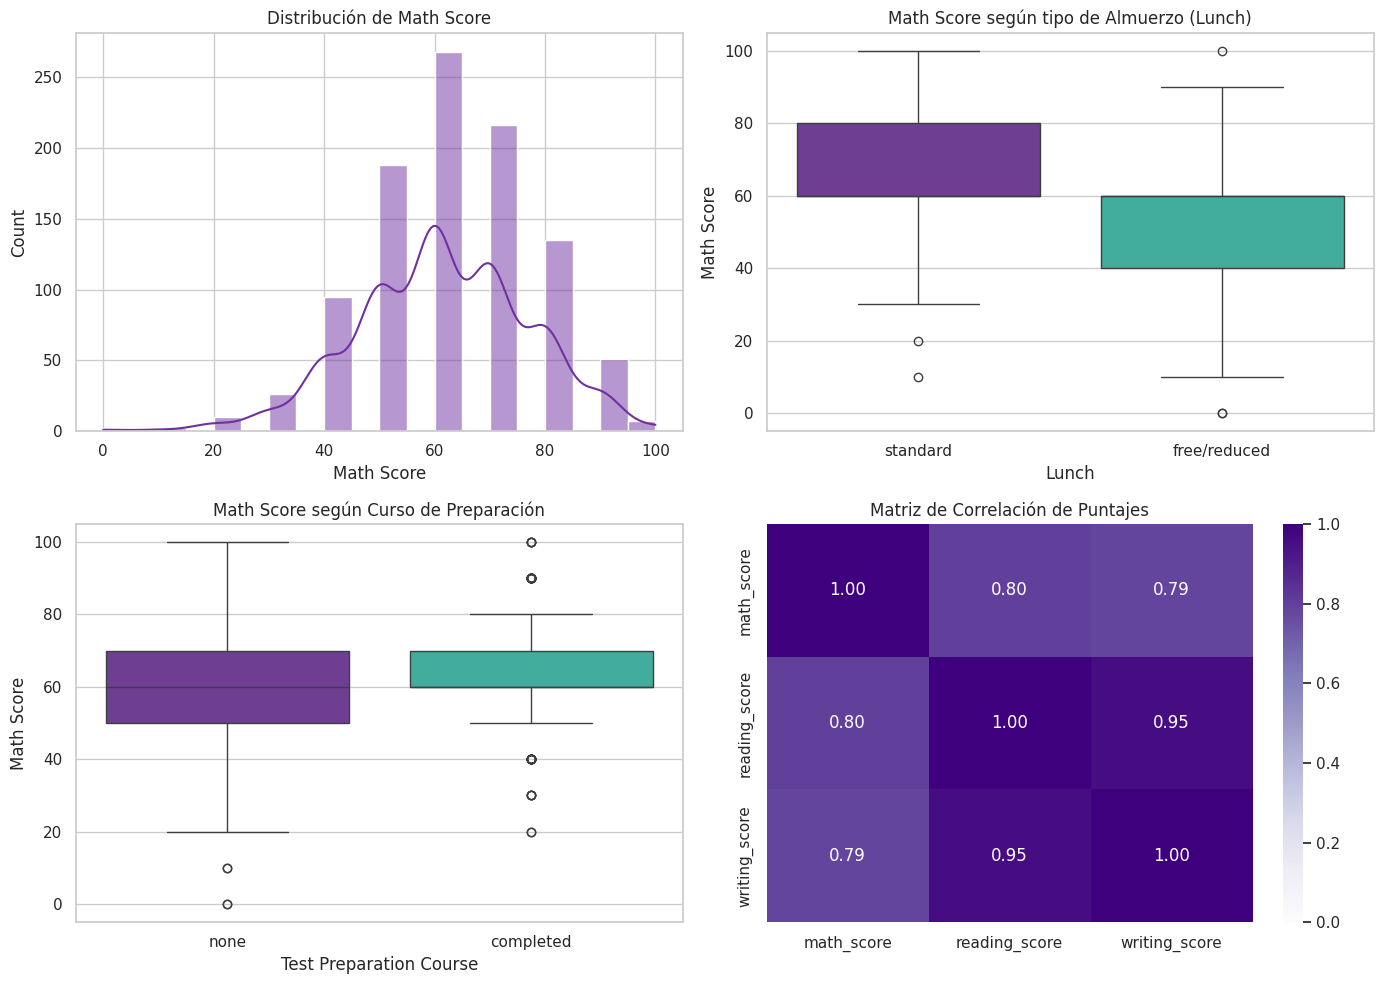

In [ ]:
# 2. Análisis exploratorio
# Graficamos la distribución de math_score y su relación con otras variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución de math_score
sns.histplot(data=estudiantes, x="math_score", bins=20, kde=True, ax=axes[0, 0], color="#7030A0")
axes[0, 0].set_title("Distribución de Math Score")
axes[0, 0].set_xlabel("Math Score")

# 2. Math Score vs Lunch
sns.boxplot(data=estudiantes, x="lunch", y="math_score", ax=axes[0, 1], palette=["#7030A0", "#30BEAA"])
axes[0, 1].set_title("Math Score según tipo de Almuerzo (Lunch)")
axes[0, 1].set_xlabel("Lunch")
axes[0, 1].set_ylabel("Math Score")

# 3. Math Score vs Test Preparation Course
sns.boxplot(data=estudiantes, x="test_preparation_course", y="math_score", ax=axes[1, 0], palette=["#7030A0", "#30BEAA"])
axes[1, 0].set_title("Math Score según Curso de Preparación")
axes[1, 0].set_xlabel("Test Preparation Course")
axes[1, 0].set_ylabel("Math Score")

# 4. Matriz de correlación
corr_matrix = estudiantes[["math_score", "reading_score", "writing_score"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="Purples", fmt=".2f", ax=axes[1, 1], vmin=0, vmax=1)
axes[1, 1].set_title("Matriz de Correlación de Puntajes")

plt.tight_layout()
plt.show()

In [ ]:
# 3 y 4. Preparación y partición

# Definir variables predictoras (X) y objetivo (y)
y = estudiantes["math_score"]
X = estudiantes.drop(columns=["math_score"])

# Identificar columnas numéricas y categóricas
cols_num = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cols_cat = X.select_dtypes(include=["object"]).columns.tolist()

# Definir el pipeline de preprocesamiento
preprocesador_estudiantes = ColumnTransformer([
    ("num", Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler())
    ]), cols_num),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cols_cat)
])

# Particionar en train y test (80/20)
X_train_est, X_test_est, y_train_est, y_test_est = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Dimensiones de X_train:", X_train_est.shape)
print("Dimensiones de X_test:", X_test_est.shape)
print("Columnas numéricas:", cols_num)
print("Columnas categóricas:", cols_cat)

In [ ]:
# 5. Modelos base y comparación de métricas
# COMPLETAR

In [ ]:
# 6. Validación cruzada
# COMPLETAR

In [ ]:
# 7 y 8. Ajuste de hiperparámetros, selección del modelo y evaluación en test
# COMPLETAR